In [ ]:
#1-d, 2-d and 3-d data points
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
#1- D - A simple array
data_1d=np.array([10,20,30,45,60,70])

print(data_1d.shape)

(6,)


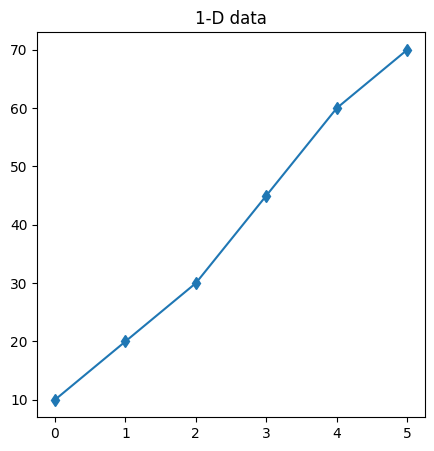

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(data_1d, marker='d')
plt.title("1-D data")
plt.show()

In [ ]:
data_2d = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
print(data_2d.shape)

(3, 3)


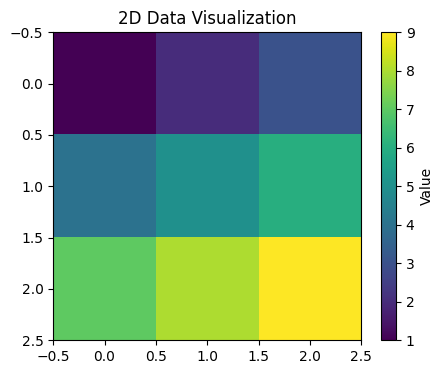

In [ ]:
plt.figure(figsize=(5, 4))
plt.imshow(data_2d, cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Data Visualization")
plt.show()

In [ ]:
#3-D plot- x, y and z
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])
z = np.array([5, 4, 3, 2, 1])

data_3d = np.column_stack((x, y, z))
print(data_3d.shape)

(5, 3)


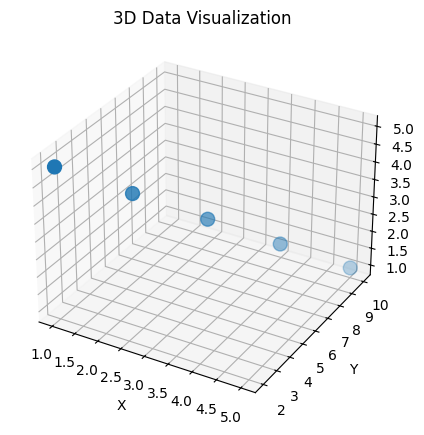

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, s=100)
ax.set_title("3D Data Visualization")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [ ]:
#Support Vector Machine
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC #Support Vector Classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_d=pd.read_csv("/content/pima indians diabetes.csv")
df_d.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#value_counts function
df_d['Outcome'].value_counts() #0- no diabetes #1- yes to diabetes
""" TP TN FP FN
    ACTUAL PREDICTED
    D         D ----- TP
    ND        ND ----- TN
    ND        D----- FP
    D         ND--- FN"""

,count
Outcome,
0,500
1,268


In [ ]:
df_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#X AND Y
x= df_d.drop('Outcome',axis=1)
y=df_d['Outcome']
print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
#SPLIT INTO TRAIN AND TEST
x_train, x_test,y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [ ]:
#NORMALIZATION
print("before normalization \n")
x_train.head()

before normalization 



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46


In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [ ]:
print("After normalization \n")
x_train_scaled

After normalization 



array([[-0.52639686, -1.15139792, -3.75268255, ..., -4.13525578,
        -0.49073479, -1.03594038],
       [ 1.58804586, -0.27664283,  0.68034485, ..., -0.48916881,
         2.41502991,  1.48710085],
       [-0.82846011,  0.56687102, -1.2658623 , ..., -0.42452187,
         0.54916055, -0.94893896],
       ...,
       [ 1.8901091 , -0.62029661,  0.89659009, ...,  1.76054443,
         1.981245  ,  0.44308379],
       [-1.13052335,  0.62935353, -3.75268255, ...,  1.34680407,
        -0.78487662, -0.33992901],
       [-1.13052335,  0.12949347,  1.43720319, ..., -1.22614383,
        -0.61552223, -1.03594038]])

•C parameter:
•Large C → Focuses on classifying all training examples correctly (can cause overfitting).
•Small C → Allows more margin violations, better generalization.
•Gamma (γ):High γ → Model focuses on close points (more complex, overfitting risk).Low γ → Model considers points farther away (simpler boundary).

In [ ]:
#MODEL BUILDING- Build the model, train the model, test the model and evalaute using metrics.
"""
1. linear-Straight line seperation(simple data)
2. poly-Polynomial transformation
3. rbf-Radial Basis Function(Default, complex models)
4. sigmoid- S-shaped value(not commonly used)"""
model=SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

#kernal- determines how is data is to be plotted or transformed.
#C is high focusses on high

In [ ]:
model.fit(x_train_scaled, y_train)

SVC(C=1, random_state=42)

In [ ]:
y_pred= model.predict(x_test_scaled)

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [ ]:
y_test

In [ ]:
#Evaluation metrics
#1. Accuracy Score
print('Accuracy',accuracy_score(y_test,y_pred))

Accuracy 0.7402597402597403


In [ ]:
#2. Precision, #Recall, #F1-Score
print('Precision',precision_score(y_test,y_pred))
print('Recall',recall_score(y_test,y_pred))
print('F1-Score',f1_score(y_test,y_pred))

Precision 0.6666666666666666
Recall 0.5454545454545454
F1-Score 0.6


In [ ]:
print('Classification report\n', classification_report(y_test,y_pred))

Classification report
               precision    recall  f1-score   support

           0       0.77      0.85      0.81        99
           1       0.67      0.55      0.60        55

    accuracy                           0.74       154
   macro avg       0.72      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [ ]:
df_d['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


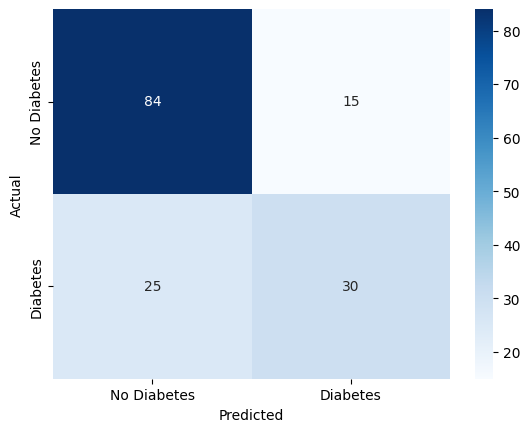

In [ ]:
#CLASS  IMBALANCE.
conf_mat=confusion_matrix(y_test, y_pred)
#Visualization of the confusion matrix
sns.heatmap(conf_mat, annot=True, cmap='Blues', xticklabels=['No Diabetes','Diabetes'], yticklabels=['No Diabetes','Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#Training and testing accuracy
print('Training accuracy', accuracy_score(y_train,model.predict(x_train_scaled)))
print('Testing accuracy', accuracy_score(y_test,model.predict(x_test_scaled)))
#Find if it is underfitting, overfitting or balanced fit?
#Judgement: Balanced fit

Training accuracy 0.8338762214983714
Testing accuracy 0.7402597402597403


In [ ]:
from sklearn.datasets import make_classification
#make_classification- Synthetic Dataset.
x1,y1=make_classification(
    n_samples=100,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    flip_y=0.5, #noise value is 0.5
    random_state=42
)
type(x1)

numpy.ndarray

In [ ]:
df_overfit=pd.DataFrame(x1,columns=[f'Feature{i}'for i in range(1,6)])
df_overfit['Target']=y1
print('Sample dataset\n',df_overfit.head())

Sample dataset
    Feature1  Feature2  Feature3  Feature4  Feature5  Target
0 -0.875618  1.943645 -0.176647 -0.781251 -1.382800       0
1 -0.019016 -0.718270 -0.157521 -0.784705 -1.002529       0
2 -0.066080  1.620937  0.166733  0.699470 -1.211016       1
3  0.270457  1.210949  0.813765 -0.351459 -0.050238       0
4  0.711615  2.215437  0.875586 -1.591460 -1.124642       1


In [ ]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x1,y1,test_size=0.3,random_state=42)

In [ ]:
x_train1_scaled=scaler.fit_transform(x_train1)
x_test1_scaled=scaler.fit_transform(x_test1)

In [ ]:
model1=SVC(kernel='rbf',C=1000,gamma=10) #Very high complexity- overfitting
model2=SVC(kernel='rbf', C=0.01, gamma=0.001) #Very low complexity - underfitting

In [ ]:
model1.fit(x_train1_scaled, y_train1)
y_pred= model1.predict(x_test1_scaled)

print('Training accuracy', accuracy_score(y_train1,model1.predict(x_train1_scaled)))
print('Testing accuracy', accuracy_score(y_test1,model1.predict(x_test1_scaled)))

Training accuracy 1.0
Testing accuracy 0.5


In [ ]:
model2.fit(x_train1_scaled, y_train1)
y_pred= model2.predict(x_test1_scaled)

print('Training accuracy', accuracy_score(y_train1,model2.predict(x_train1_scaled)))
print('Testing accuracy', accuracy_score(y_test1,model2.predict(x_test1_scaled)))

Training accuracy 0.5285714285714286
Testing accuracy 0.5333333333333333
